In [ ]:
import numpy as np
xf_train = np.load("processed-imgs/xf_train.npy")
xf_test = np.load("processed-imgs/xf_test.npy")
y_train = np.load("processed-imgs/y_train.npy")
y_test = np.load("processed-imgs/y_test.npy")
xi_train = np.load("processed-imgs/xi_train.npy")
xi_test = np.load("processed-imgs/xi_test.npy")
x_train_scaled = np.load("processed-imgs/xf_train_scaled.npy")
x_test_scaled = np.load("processed-imgs/xf_test_scaled.npy")



In [ ]:
xf_train

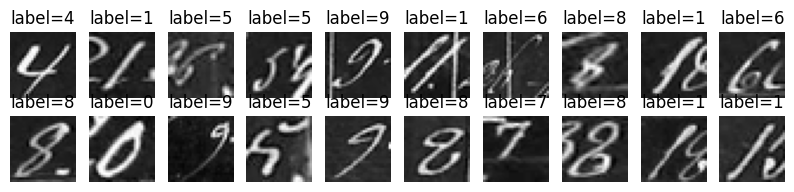

In [4]:
from plot_sample import plot_sample
plot_sample(xi_train, y_train)

# Multi Classification


In [5]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import  cross_validate
from time import time
log_reg_multi = SGDClassifier(loss='log_loss' , random_state=42)



In [6]:
help(SGDClassifier)

Help on class SGDClassifier in module sklearn.linear_model._stochastic_gradient:

class SGDClassifier(BaseSGDClassifier)
 |  SGDClassifier(loss='hinge', *, penalty='l2', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001, shuffle=True, verbose=0, epsilon=0.1, n_jobs=None, random_state=None, learning_rate='optimal', eta0=0.0, power_t=0.5, early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, class_weight=None, warm_start=False, average=False)
 |
 |  Linear classifiers (SVM, logistic regression, etc.) with SGD training.
 |
 |  This estimator implements regularized linear models with stochastic
 |  gradient descent (SGD) learning: the gradient of the loss is estimated
 |  each sample at a time and the model is updated along the way with a
 |  decreasing strength schedule (aka learning rate). SGD allows minibatch
 |  (online/out-of-core) learning via the `partial_fit` method.
 |  For best results using the default learning rate schedule, the data should


In [3]:
from sklearn.model_selection import GridSearchCV
param={
    'penalty' : ['l1' , 'l2' , None] ,
    'alpha' : [0.0001 , 0.001 , 0.01] , 
    'max_iter': [1000 , 1500 , 2000] , 
    'tol' : [1e-2 , 1e-3 , 1e-4],
    'learning_rate' :['constant'] ,
    'eta0' : [0.01 , 0.001 , 0.005 , 0.05] ,
    'early_stopping' : [True , False] 
}
grid = GridSearchCV(log_reg_multi , param ,cv=5 , verbose=1 , return_train_score=True )
grid.fit(x_train_scaled , y_train )

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


,estimator,SGDClassifier...ndom_state=42)
,param_grid,"{'alpha': [0.0001, 0.001, ...], 'early_stopping': [True, False], 'eta0': [0.01, 0.001, ...], 'learning_rate': ['constant'], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,loss,'log_loss'


In [4]:
grid.best_params_

{'alpha': 0.001,
 'early_stopping': False,
 'eta0': 0.001,
 'learning_rate': 'constant',
 'max_iter': 1000,
 'penalty': 'l1',
 'tol': 0.001}

In [5]:
import joblib
joblib.dump(grid.best_estimator_ , 'best_sgdclassifier.pkl')


['best_sgdclassifier.pkl']

In [6]:
import pandas as pd
grid_result = pd.DataFrame(grid.cv_results_)
grid_result = grid_result.sort_values(by='rank_test_score')
#cols = ['params' , 'mean_test_score' , 'std_test_score' , 'rank_test_score']
grid_result[:21].to_csv('grid_sgdclassifier.csv',index=False) 

In [25]:
log1 = SGDClassifier(random_state=42, alpha=0.0001, early_stopping=False, eta0=0.01, learning_rate='constant', max_iter=2000,
             penalty='l1')
log1.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {log1.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {log1.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 75.49 % 
Test Accuracy : 65.95 % 


In [26]:
log2 = SGDClassifier(random_state=42, alpha=0.001, early_stopping=False, eta0=0.01, learning_rate='constant', max_iter=2000,
             penalty='l1')
log2.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {log2.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {log2.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 74.35 % 
Test Accuracy : 70.40 % 


In [27]:
log3 = SGDClassifier(random_state=42, alpha=0.01, early_stopping=False, eta0=0.01, learning_rate='adaptive', max_iter=2000,
             penalty='l1')
log3.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {log3.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {log3.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 72.90 % 
Test Accuracy : 70.40 % 


In [31]:
log4 = SGDClassifier(random_state=42, alpha=0.001, early_stopping=False, eta0=0.001, learning_rate='constant', max_iter=2000,
             penalty='l1')
log4.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {log4.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {log4.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 80.44 % 
Test Accuracy : 74.00 % 


In [35]:
log5 = SGDClassifier(random_state=42, alpha=0.001, early_stopping=True, eta0=0.001, learning_rate='adaptive', max_iter=2000,
             penalty='l1')
log5.fit(x_train_scaled , y_train)
print(f"Train Accuracy : {log5.score(x_train_scaled , y_train)*100:.2f} % ")
print(f"Test Accuracy : {log5.score(x_test_scaled , y_test)*100:.2f} % ")

Train Accuracy : 81.23 % 
Test Accuracy : 75.80 % 


In [36]:
import joblib
best_model = joblib.load('best_sgdclassifier.pkl')

In [38]:
print(best_model.score(x_train_scaled , y_train)*100)
print(best_model.score(x_test_scaled , y_test)*100)

80.825
75.9


## will consider the grid parameters

In [39]:
start = time()
kf_scores=cross_validate(best_model, x_train_scaled, y_train, cv=5, scoring='accuracy',return_train_score=True
,verbose=5555)
time_log_multi_sgd_kf = time() - start
print(f"KFold Cross-validation train time: {time_log_multi_sgd_kf:.2f} seconds")
print(f"KFold Cross-validation train Accuracy scores: {kf_scores['train_score']}")
print(f"KFold Cross-validation test Accuracy scores: {kf_scores['test_score']}")

[CV] START .....................................................................
[CV] END ..................., score=(train=0.812, test=0.741) total time=  14.8s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   14.8s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.811, test=0.772) total time=  14.2s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   29.1s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.815, test=0.744) total time=  14.9s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:   44.2s
[CV] START .....................................................................
[CV] END ..................., score=(train=0.806, test=0.748) total time=  13.5s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   57.7s
[CV] START .....................................................................
[CV] END ..................

In [42]:
avg_kf_score_log_multi_sgd_train = np.mean(kf_scores['train_score'])
print(f"Average KFold Cross-validation train Accuracy: {avg_kf_score_log_multi_sgd_train:.4f}")
std_kf_score_log_multi_sgd_train = np.std(kf_scores['train_score'])
print(f"Standard Deviation of KFold Cross-validation train Accuracy: {std_kf_score_log_multi_sgd_train:.4f}")

avg_kf_score_log_multi_sgd_test = np.mean(kf_scores['test_score'])
print(f"Average KFold Cross-validation test Accuracy: {avg_kf_score_log_multi_sgd_test:.4f}")
std_kf_score_log_multi_sgd_test = np.std(kf_scores['test_score'])
print(f"Standard Deviation of KFold Cross-validation  test Accuracy: {std_kf_score_log_multi_sgd_test:.4f}")

Average KFold Cross-validation train Accuracy: 0.8116
Standard Deviation of KFold Cross-validation train Accuracy: 0.0032
Average KFold Cross-validation test Accuracy: 0.7508
Standard Deviation of KFold Cross-validation  test Accuracy: 0.0109


In [44]:
start = time()
best_model.fit(x_train_scaled, y_train)
time_log_multi_sgd_kf += time() - start

In [45]:
y_test_pred = best_model.predict(x_test_scaled)
y_train_pred = best_model.predict(x_train_scaled)
y_test_pred

array([9, 7, 3, ..., 2, 2, 9], dtype=int64)

#### sklearn hard rule : anny probability have to be probabiluty distribution

In [47]:
sum(best_model.predict_proba(xf_test)[999])

1.0000000391155481

In [48]:
print(f"Logistic Regression SGD Multinomial Train Accuracy: {best_model.score(x_train_scaled, y_train):.4f}")

print(f"Logistic Regression SGD Multinomial Test Accuracy: {best_model.score(x_test_scaled, y_test):.4f}")

Logistic Regression SGD Multinomial Train Accuracy: 0.8083
Logistic Regression SGD Multinomial Test Accuracy: 0.7590


In [49]:
from cmetrics import *
accuracy_log_multi_sgd = acc(y_test, y_test_pred)
print(f"Logistic Regression SGD Multi Accuracy: {accuracy_log_multi_sgd:.4f}%")
prec_log_multi_sgd = precision(y_test, y_test_pred)
print(f"Logistic Regression SGD Multi Precision: {prec_log_multi_sgd:.4f}%")
rec_log_multi_sgd = recall(y_test, y_test_pred)
print(f"Logistic Regression SGD Multi Recall: {rec_log_multi_sgd:.4f}%")
f1_score_log_multi_sgd = f1(y_test, y_test_pred)
print(f"Logistic Regression SGD Multi F1 Score: {f1_score_log_multi_sgd:.4f}%")

Logistic Regression SGD Multi Accuracy: 75.9000%
Logistic Regression SGD Multi Precision: 75.8430%
Logistic Regression SGD Multi Recall: 75.9000%
Logistic Regression SGD Multi F1 Score: 75.7873%


In [50]:
import json

metrics = {
    "accuracy": accuracy_log_multi_sgd,
    "precision": prec_log_multi_sgd,
    "recall": rec_log_multi_sgd,
    "f1_score": f1_score_log_multi_sgd,
    "train_time": time_log_multi_sgd_kf
}

with open("experiments/log_multi_sgd.json", "w") as f:
    json.dump(metrics, f, indent=4)


In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.80       200
           1       0.75      0.81      0.78       200
           2       0.75      0.72      0.74       200
           3       0.81      0.77      0.78       200
           4       0.74      0.76      0.75       200
           5       0.77      0.77      0.77       200
           6       0.79      0.87      0.83       200
           7       0.74      0.71      0.72       200
           8       0.72      0.62      0.67       200
           9       0.73      0.76      0.75       200

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



In [52]:
cm=conf_matrix(y_test, y_test_pred)
cm

array([[162,   6,   1,   2,   6,   3,   7,   2,   4,   7],
       [  4, 161,   4,   5,   1,   4,   1,  10,   8,   2],
       [  3,   7, 144,   9,   5,   5,   3,   7,   5,  12],
       [  7,   4,   8, 153,  11,   5,   0,   5,   4,   3],
       [  5,   8,   3,   0, 152,   4,  11,   4,   6,   7],
       [  8,   3,   4,   3,   3, 154,  13,   5,   7,   0],
       [  0,   8,   1,   1,   1,  11, 174,   0,   4,   0],
       [  1,   9,  11,   2,   4,   0,   2, 142,   8,  21],
       [  9,   8,   8,   5,  14,  13,   8,   7, 124,   4],
       [  8,   1,   7,  10,   9,   1,   0,  10,   2, 152]], dtype=int64)

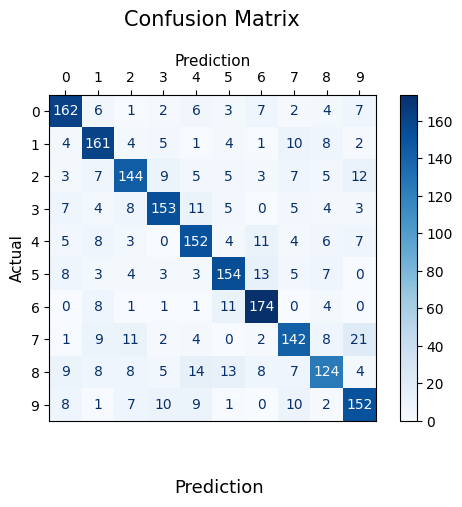

In [53]:
plot_confusion_matrix(cm)